In [24]:
import sys
sys.path.append('../src/')

import numpy as np
import matplotlib.pyplot as plt
from simplex_bisection import *
from broyden import broyden_solver

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from functools import cache
class fun:
  '''
  Simple overdermined system with unique solution
  x=0.3, y=0.4
  '''
  def __init__(self, noise=0.0):
    self.calls = 0
    self.noise = noise
  def __call__(self, x, y):
    out = np.array([x+y-0.7, x-y+0.1, 2*x+y-1])
    out += self.noise * np.random.randn(*out.shape)
    return out
  @cache
  def lookup_table(self, _x):
    self.calls += 1
    x = np.array(_x)
    out = np.array([x[0]+x[1]-0.7, x[0]-x[1]+0.1, 2*x[0]+x[1]-1])
    out += self.noise * np.random.randn(*out.shape)
    return out
  def plot(self, x_range=(0,1), y_range=(0,1)):
    X, Y = np.meshgrid(np.linspace(*x_range,100), np.linspace(*y_range,100))
    f1, f2, f3 = self(X,Y)
    plt.contourf(X,Y,f1**2 + f2**2 + f3**2, levels=20, cmap='RdBu_r')
    plt.plot(0.3, 0.4, '*', label='True solution', markersize=20)
    plt.title(f'Number of function calls = {self.calls}')
fun()(0.3,0.4)

array([ 0.00000000e+00, -2.77555756e-17,  0.00000000e+00])

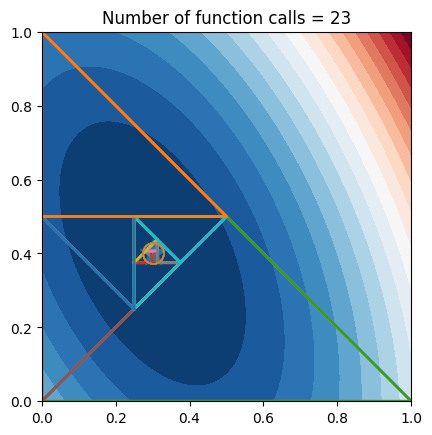

In [28]:
f = fun()
root, _ = SimplexBisection(f, dimension=2, max_depth=20, exploration=True, bisect_parent=True);
f.plot()
root.plot_all()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from functools import cache

class himmelblau_fun:
    '''
    Vector-valued version of Himmelblau's function:
    f(x, y) = [x^2 + y - 11, x + y^2 - 7]
    Has four global minima:
      (3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)
    '''
    def __init__(self, noise=0.0):
        self.noise = noise
        self.calls = 0

    def __call__(self, x, y):
        self.calls += 1
        out = np.array([x**2 + y - 11., x + y**2 - 7.])
        out += self.noise * np.random.randn(*out.shape)
        return out

    @cache
    def lookup_table(self, _x):
        self.calls += 1
        x = np.array(_x)
        out = np.array([x[0]**2 + x[1] - 11., x[0] + x[1]**2 - 7.])
        out += self.noise * np.random.randn(*out.shape)
        return out

    def plot(self, x_range=(-6, 6), y_range=(-6, 6)):
        X, Y = np.meshgrid(np.linspace(*x_range, 400), np.linspace(*y_range, 400))
        f1, f2 = self(X, Y)
        Z = f1**2 + f2**2
        plt.contourf(X, Y, Z, levels=40, cmap='RdBu_r')
        # plot one of the known minima
        minima = [(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
        for i, (xm, ym) in enumerate(minima):
            plt.plot(xm, ym, '*', label=f'minimum {i+1}', markersize=12)
        plt.title(f'Himmelblau function ||f(x,y)||²\nFunction calls: {self.calls}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.colorbar(label='||f(x, y)||²')
        plt.legend()

(-6.0, 6.0)

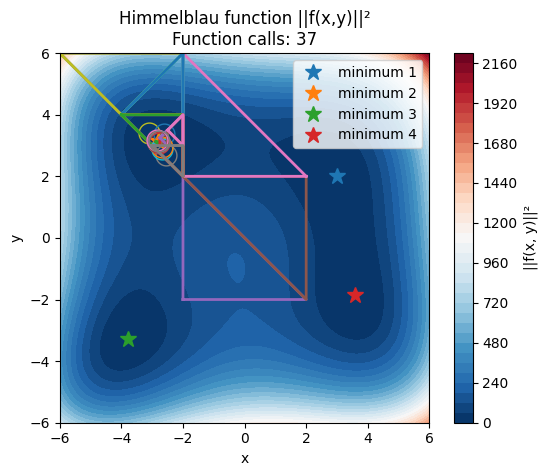

In [30]:
f = himmelblau_fun()
root = Simplex(dimension=2, vertices=[[-2,-2],[2,-2],[-2,2]])
root, _ = SimplexBisection(f, dimension=2, max_depth=30, exploration=True, root=root, bisect_parent=True);
f.plot()
root.plot_all()
plt.xlim([-6,6])
plt.ylim([-6,6])

In [33]:
class fun3D:
    '''
    Linear overdetermined system in 3D:
    4 equations in 3 variables (x, y, z)
    True solution: x = 0.3, y = 0.4, z = 0.2
    '''
    def __init__(self, noise=0.0):
        self.calls = 0
        self.noise = noise

    def __call__(self, x):
        x = np.asarray(x)
        A = np.array([
            [1, 1, 1],
            [1, -1, 0],
            [2, 0, 1],
            [0, 1, -2],
        ])
        b = A @ np.array([0.3, 0.4, 0.2])  # Ensures known solution
        out = A @ x - b
        out += self.noise * np.random.randn(*out.shape)
        return out

    @cache
    def lookup_table(self, _x):
        self.calls += 1
        #print(f'Call: {self.calls}, accuracy: {np.linalg.norm(np.array([0.3, 0.4, 0.2]) - np.array(_x))}')
        return self(np.array(_x))

    def plot(self):
      plt.gca().scatter(0.3, 0.4, 0.2, color='b', s=50) 
fun3D()([0.3, 0.4, 0.2])

array([0., 0., 0., 0.])

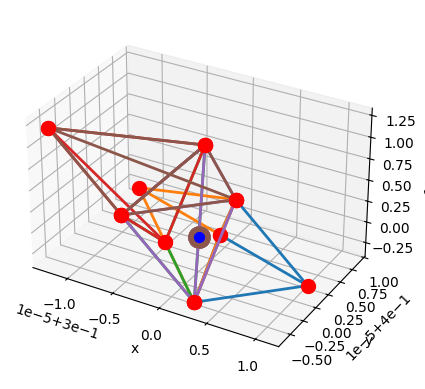

In [34]:
f = fun3D()
root, out = SimplexBisection(f, dimension=3, max_depth=50, bisect_parent=True);
plt.gcf().add_subplot(111, projection='3d')
root.plot_all(50)
fun3D().plot()

In [84]:
class fun3D_nonlinear:
    '''
    Nonlinear overdetermined system in 3D:
    6 equations in 3 variables (x, y, z)
    True solution: x = 0.3, y = 0.4, z = 0.2
    '''
    def __init__(self, noise=0.0):
        self.calls = 0
        self.noise = noise
        self.errors = []

    def true_solution(self):
        return np.array([0.3, 0.4, 0.2])

    def __call__(self, x):
        x = np.asarray(x)
        self.calls += 1
        self.errors.append(np.linalg.norm(np.array(x)-np.array([0.3, 0.4, 0.2])))
        
        x0, x1, x2 = x
        x_true = self.true_solution()
        x0t, x1t, x2t = x_true

        # Define nonlinear system
        out = np.array([
            x0**2 + x1 + np.sin(x2) - (x0t**2 + x1t + np.sin(x2t)),
            x1**2 + x2 + np.sin(x0) - (x1t**2 + x2t + np.sin(x0t)),
            x2**2 + x0 + np.sin(x1) - (x2t**2 + x0t + np.sin(x1t)),
            x0 * x1 + x2**2 - (x0t * x1t + x2t**2),
            x1 * x2 + x0**2 - (x1t * x2t + x0t**2),
            x0 * x2 + x1**2 - (x0t * x2t + x1t**2),
        ])
        out += self.noise * np.random.randn(*out.shape)
        return out

    @cache
    def lookup_table(self, _x):
        return self(np.array(_x))

    def plot(self):
        x, y, z = self.true_solution()
        plt.gca().scatter(x, y, z, color='blue', s=60, label='True solution')
        plt.legend()

fun3D_nonlinear()([0.3, 0.4, 0.2])
#Simplex(dimension=3).is_x_inside([0.3, 0.4, 0.2])

array([0., 0., 0., 0., 0., 0.])

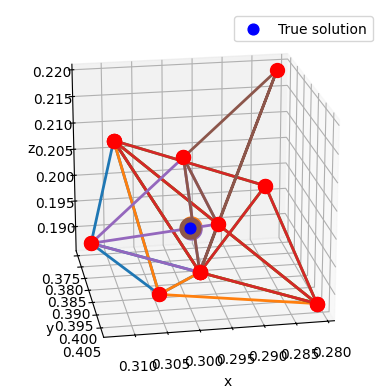

In [85]:
f = fun3D_nonlinear()
root, out = SimplexBisection(f, dimension=3, max_depth=20
                            , exploration=True, bisect_parent=True);
plt.gcf().add_subplot(111, projection='3d')
root.plot_all(min_depth=17)
f.plot()
plt.gca().view_init(elev=20, azim=-1000)  # Adjust these values as you want

In [91]:
f_broyden = fun3D_nonlinear()
broyden_solver(f_broyden, np.zeros(3))

Stop. Update is too small at iteration 14


array([0.3, 0.4, 0.2])

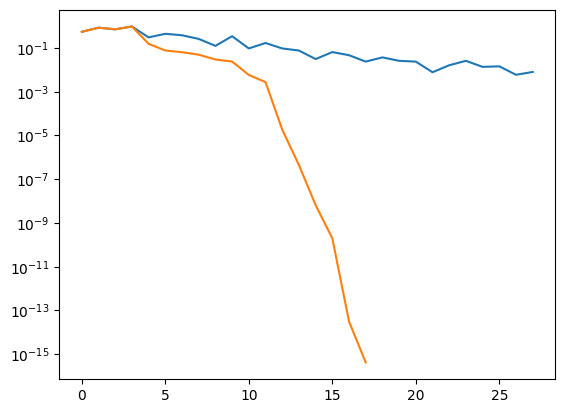

In [92]:
plt.plot(f.errors)
plt.plot(f_broyden.errors)
plt.yscale('log')

In [ ]:
b